In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from temgym_core.components import Detector
from temgym_core.gaussian import square_input_wave, AtomicPotential, run_to_end_vmapped
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.potential import potential, potential_smoothed, Si
from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [2]:
r_sharp, spacing = np.linspace(-10, 10, 512, retstep=True)
r_smooth = np.linspace(-10, 10, 2048, retstep=False)
V = potential(abs(r_sharp), Si)
V0 = potential(abs(jnp.array([spacing/2])), Si)
V_smooth = potential_smoothed(abs(r_smooth), Si, spacing / 3)

In [3]:
V_integrated_area = np.trapz(V, x=r_sharp)
V_smoothed_integrated_area = np.trapz(V_smooth, x=r_smooth)

print("Integrated area of raw potential: ", V_integrated_area)
print("Integrated area of smoothed potential: ", V_smoothed_integrated_area)

Integrated area of raw potential:  29.00356489900095
Integrated area of smoothed potential:  29.225261795209008


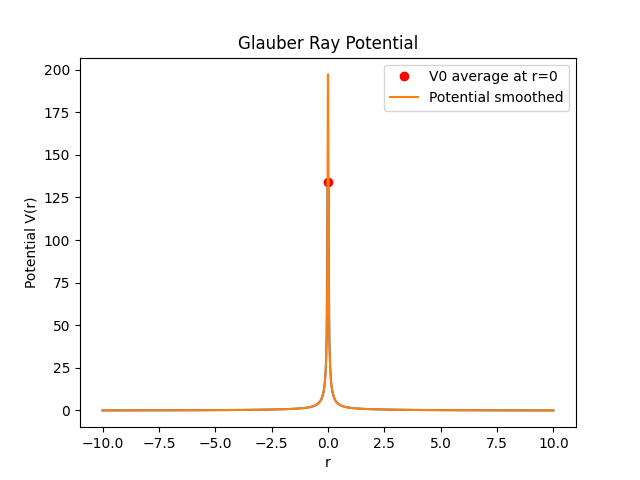

In [4]:
plt.figure()
plt.plot(r_sharp, V)
plt.plot(0, abs(V0), 'ro', label='V0 average at r=0')
plt.plot(r_smooth, V_smooth, label='Potential smoothed')
plt.xlabel('r')
plt.ylabel('Potential V(r)')
plt.title('Glauber Ray Potential')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Glauber Ray Potential in 2D')

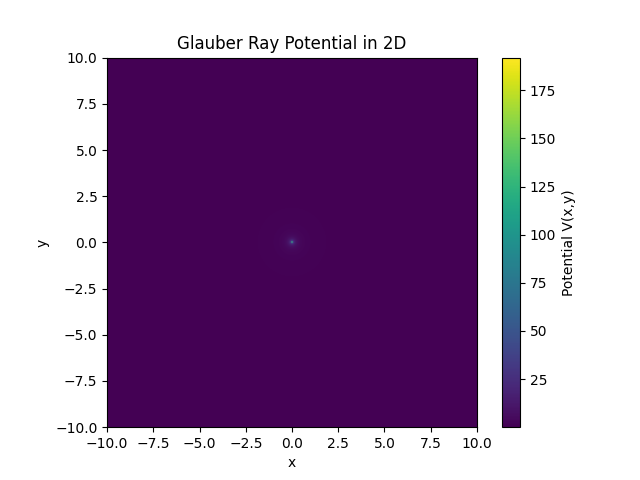

In [5]:
potential_2D = lambda r, p: potential_smoothed(jnp.sqrt(r[0]**2 + r[1]**2), p, spacing / 3)
image = jax.vmap(
    jax.vmap(lambda x, y: potential_2D(jnp.array([x, y]), Si), in_axes=(0, None)),
    in_axes=(None, 0)
)(r_smooth, r_smooth)
 
plt.figure()
plt.imshow(image, extent=(r_smooth[0], r_smooth[-1], r_smooth[0], r_smooth[-1]))
plt.colorbar(label='Potential V(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Glauber Ray Potential in 2D')

In [6]:
rays_in = square_input_wave(aperture_length=30, waist=0.05, voltage=100e3, wavelength_unit='angstrom')
print('Number of Input Rays:', rays_in.r_xy.shape[0])
detector_at_slice = Detector(z=0.0, pixel_size=(spacing, spacing), shape=(512, 512))
atom = AtomicPotential(atom_xyz=jnp.array([0.0, 0.0, 0.0]), element_params=Si, cutoff_radius=spacing/3)

propagation = 5
detector_at_propagation = Detector(z=propagation, pixel_size=(spacing, spacing), shape=(512, 512))

input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, detector_at_slice)

rays_after_slice = run_to_end_vmapped(rays_in, (atom,))
field_after_slice = evaluate_gaussians_gpu_kernel_wrapper(rays_after_slice, detector_at_slice)

rays_after_propagation = run_to_end_vmapped(rays_in, (atom, detector_at_propagation))
field_after_propagation = evaluate_gaussians_gpu_kernel_wrapper(rays_after_propagation, detector_at_propagation)

Number of Input Rays: 1440000


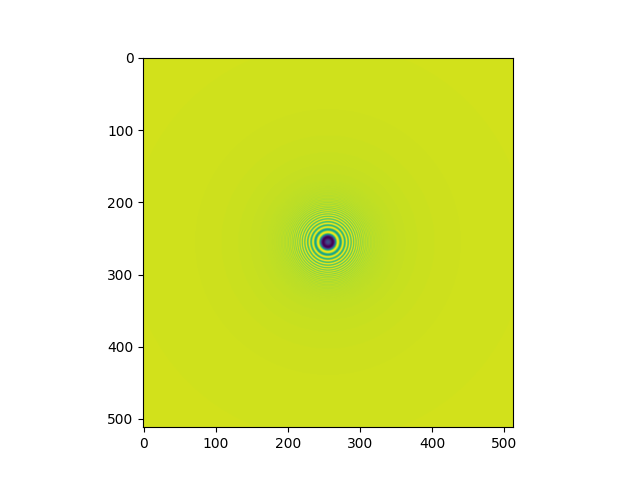

In [7]:
plt.figure()
plt.imshow(jnp.angle(field_after_propagation))

In [8]:
sigma = rays_in.sigma
k = rays_in.k
xy = rays_in.r_xy
atom_phase_shift = jax.vmap(atom.phase_shift, in_axes=(0, None, None, None))(detector_at_propagation.coords, 0.0, sigma[0], k[0]).reshape(detector_at_propagation.shape)
atom_phase_shift = jnp.exp(1j * k[0] * atom_phase_shift)

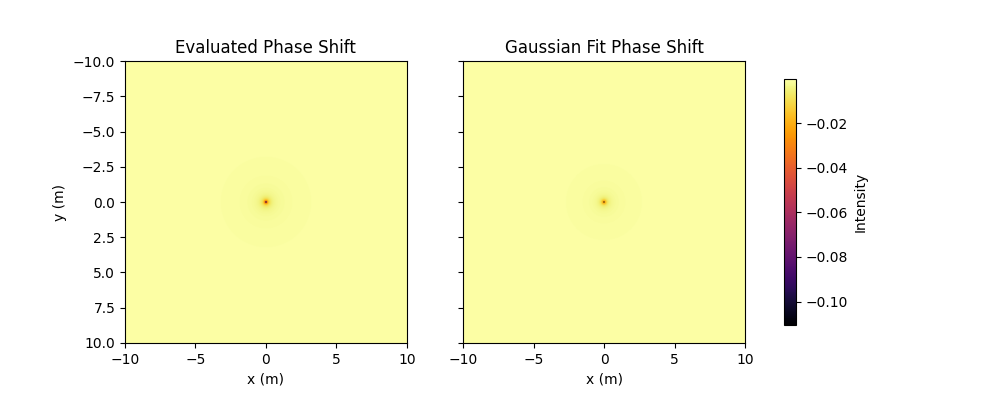

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
im0 = axes[0].imshow(jnp.angle(atom_phase_shift), extent=detector_at_propagation.extent, cmap='inferno')
axes[0].set_title('Evaluated Phase Shift')
im1 = axes[1].imshow(jnp.angle(field_after_slice), extent=detector_at_propagation.extent, cmap='inferno')
axes[1].set_title('Gaussian Fit Phase Shift')
for ax in axes:
    ax.set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8, label='Intensity')
plt.show()


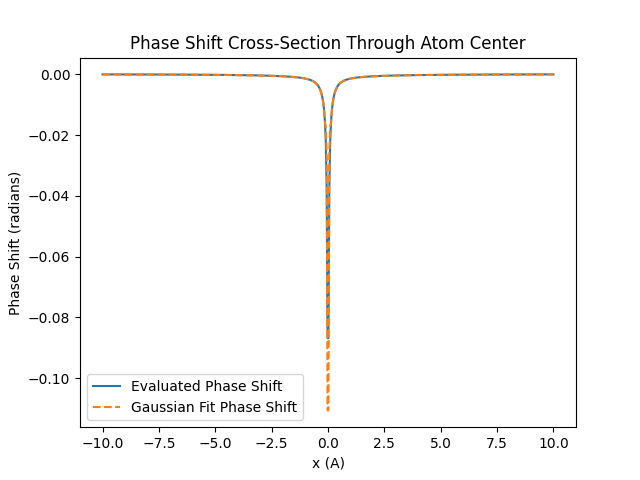

In [10]:
cross_section_gaussian_phase_shift = field_after_slice[detector_at_propagation.shape[0]//2, :]
cross_section_evaluated_phase_shift = atom_phase_shift[detector_at_propagation.shape[0]//2, :]

plt.figure()
plt.plot(detector_at_propagation.coords_1d[0], np.angle(cross_section_evaluated_phase_shift), label='Evaluated Phase Shift')
plt.plot(detector_at_propagation.coords_1d[0], np.angle(cross_section_gaussian_phase_shift), label='Gaussian Fit Phase Shift', linestyle='dashed')
plt.xlabel('x (A)')
plt.ylabel('Phase Shift (radians)')
plt.title('Phase Shift Cross-Section Through Atom Center')
plt.legend()

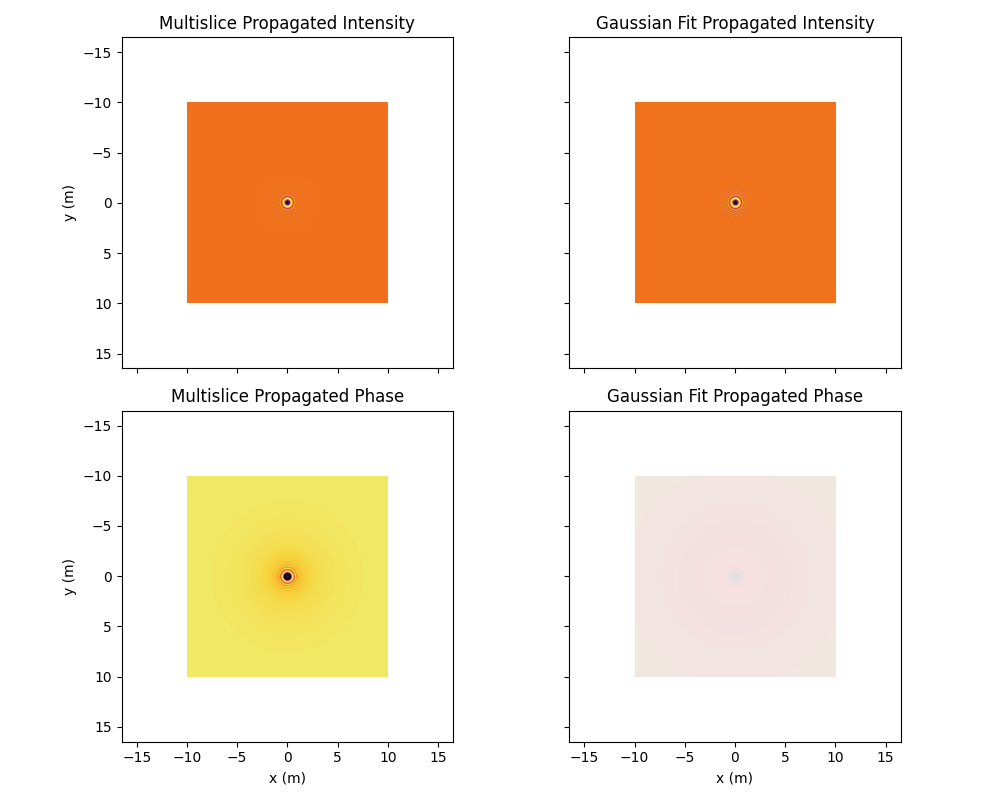

In [11]:
multislice_propagated_field = FresnelPropagator(atom_phase_shift, L=20, wavelength=rays_in.wavelength[0], z=propagation)
gaussian_propagated_field = field_after_propagation

fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
im0 = axs[0, 0].imshow(jnp.abs(multislice_propagated_field), extent=detector_at_propagation.extent, cmap='inferno')
axs[0, 0].set_title('Multislice Propagated Intensity')
axs[0, 0].set_ylabel('y (m)')

im1 = axs[0, 1].imshow(jnp.abs(gaussian_propagated_field), extent=detector_at_propagation.extent, cmap='inferno')
axs[0, 1].set_title('Gaussian Fit Propagated Intensity')

im2 = axs[1, 0].imshow(jnp.angle(multislice_propagated_field), extent=detector_at_propagation.extent, cmap='inferno')
axs[1, 0].set_title('Multislice Propagated Phase')
axs[1, 0].set_xlabel('x (m)')
axs[1, 0].set_ylabel('y (m)')

im3 = axs[1, 1].imshow(jnp.angle(gaussian_propagated_field), extent=detector_at_propagation.extent, cmap='inferno')
axs[1, 1].plot(rays_after_propagation.x, rays_after_propagation.y, 'w.', markersize=4, alpha=0.03)
axs[1, 1].set_title('Gaussian Fit Propagated Phase')
axs[1, 1].set_xlabel('x (m)')

plt.tight_layout()
plt.show()

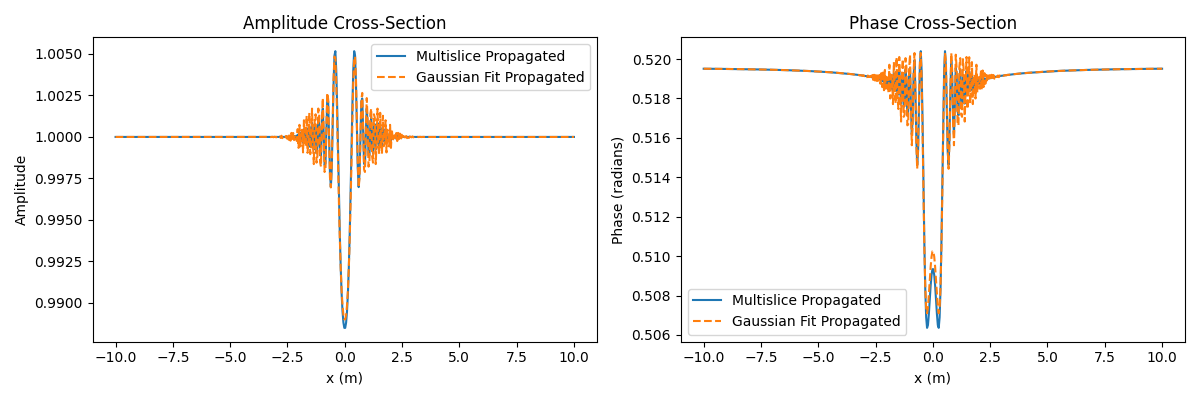

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cross section of amplitude
cross_section_multislice_amp = jnp.abs(multislice_propagated_field[detector_at_propagation.shape[0]//2, :])
cross_section_gaussian_amp = jnp.abs(gaussian_propagated_field[detector_at_propagation.shape[0]//2, :])

axes[0].plot(detector_at_propagation.coords_1d[0], cross_section_multislice_amp, label='Multislice Propagated')
axes[0].plot(detector_at_propagation.coords_1d[0], cross_section_gaussian_amp, label='Gaussian Fit Propagated', linestyle='dashed')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Amplitude Cross-Section')
axes[0].legend()

# Cross section of phase
cross_section_multislice_phase = jnp.angle(multislice_propagated_field[detector_at_propagation.shape[0]//2, :])
cross_section_gaussian_phase = jnp.angle(gaussian_propagated_field[detector_at_propagation.shape[0]//2, :])

axes[1].plot(detector_at_propagation.coords_1d[0], cross_section_multislice_phase, label='Multislice Propagated')
axes[1].plot(detector_at_propagation.coords_1d[0], cross_section_gaussian_phase, label='Gaussian Fit Propagated', linestyle='dashed')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('Phase (radians)')
axes[1].set_title('Phase Cross-Section')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from temgym_core.potential import glauber_amplitude_vmap
sigma = rays_in.sigma[0]
k = rays_in.k[0]
r_pix = spacing / 3
b_max = 10
nb = 512
z_max = 5
nz = 512
q_max = 10  # 16 Angstrom^-1


q_vals = jnp.linspace(0.0, q_max, 200)  # e.g. scattering vector range

f_q_vals = glauber_amplitude_vmap(
    q_vals, k, Si, r_pix,
    b_max, nb,
    z_max, nz,
    sigma
)
d_sigma_dOmega = jnp.abs(f_q_vals)**2

In [23]:
print(f_q_vals)

[            nan           +nanj             nan           +nanj
             nan           +nanj             nan           +nanj
  1.54617414e-01+1.13881504e-03j  7.64968037e-02+8.41005539e-04j
  5.43240107e-02+6.60202594e-04j  5.85438978e-02+5.39763600e-04j
  5.64785241e-02+4.51934218e-04j  3.99843921e-02+3.83704969e-04j
  1.82722819e-02+3.29338176e-04j  3.09482744e-02+2.89857593e-04j
 -1.13631325e-02+2.49675736e-04j  1.16132051e-01+2.38176816e-04j
 -2.10101311e-02+1.99766526e-04j -1.62029321e-01+1.59422659e-04j
 -8.78206573e-03+1.57192983e-04j  2.43616685e-01+1.74787528e-04j
  3.08274711e-01+1.76214802e-04j  1.20762624e-01+1.48183888e-04j
 -1.89857121e-01+1.01646689e-04j -4.50229112e-01+5.61952829e-05j
 -5.45730012e-01+2.72836489e-05j -4.47414587e-01+2.14776864e-05j
 -1.92606227e-01+3.73723007e-05j  1.48159865e-01+6.87090068e-05j
  4.99386984e-01+1.07469479e-04j  7.98133854e-01+1.46051993e-04j
  1.00158428e+00+1.78437388e-04j  1.08775093e+00+2.00580161e-04j
  1.05240768e+00+2.103199

Text(0.5, 1.0, 'Glauber Ray Differential Cross Section')

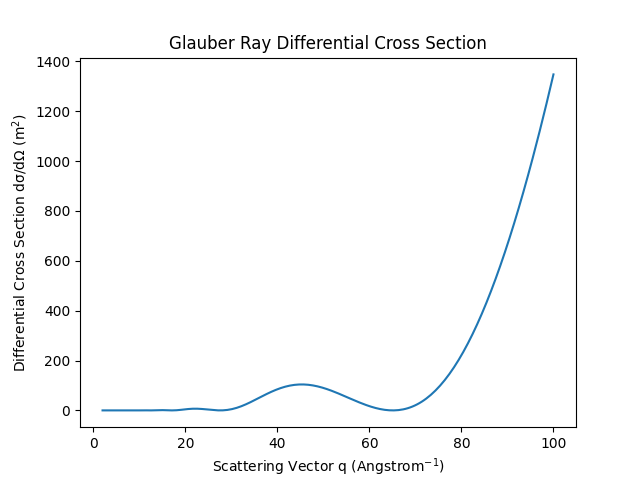

In [24]:
plt.figure()
plt.plot(q_vals, abs(f_q_vals)**2)
plt.xlabel('Scattering Vector q (Angstrom$^{-1}$)')
plt.ylabel('Differential Cross Section dσ/dΩ (m$^{2}$)')
plt.title('Glauber Ray Differential Cross Section')